# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


[ResNet-18] Epoch   1/100 | LR: 2.93e-04 | train loss 0.8636 acc 0.679 | val loss 0.5658 acc 0.766 *


[ResNet-18] Epoch   2/100 | LR: 2.93e-04 | train loss 0.7430 acc 0.720 | val loss 0.5943 acc 0.747


[ResNet-18] Epoch   3/100 | LR: 2.93e-04 | train loss 0.6838 acc 0.719 | val loss 0.5535 acc 0.713 *


[ResNet-18] Epoch   4/100 | LR: 2.93e-04 | train loss 0.6735 acc 0.718 | val loss 0.4716 acc 0.809 *


...

[ResNet-18] Epoch  18/100 | LR: 2.93e-04 | train loss 0.4115 acc 0.850 | val loss 0.5395 acc 0.778


[ResNet-18] Epoch  19/100 | LR: 2.93e-04 | train loss 0.4329 acc 0.853 | val loss 0.5530 acc 0.775


[ResNet-18] Epoch  20/100 | LR: 2.93e-04 | train loss 0.3395 acc 0.885 | val loss 0.5826 acc 0.750


[ResNet-18] Epoch  21/100 | LR: 2.93e-04 | train loss 0.3854 acc 0.853 | val loss 0.4749 acc 0.800


[ResNet-18] Epoch  22/100 | LR: 2.93e-04 | train loss 0.3459 acc 0.869 | val loss 0.4274 acc 0.816

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 22.

[ResNet-18] Restored best checkpoint (val loss = 0.3299)


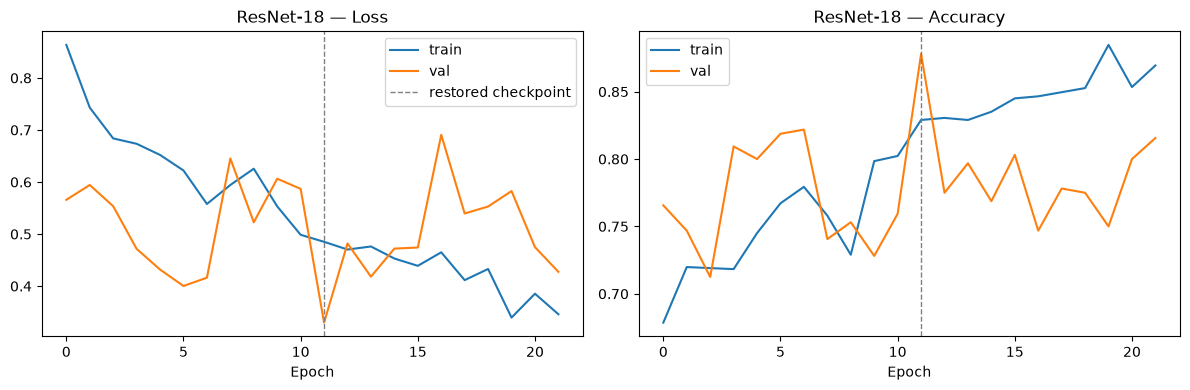

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.611


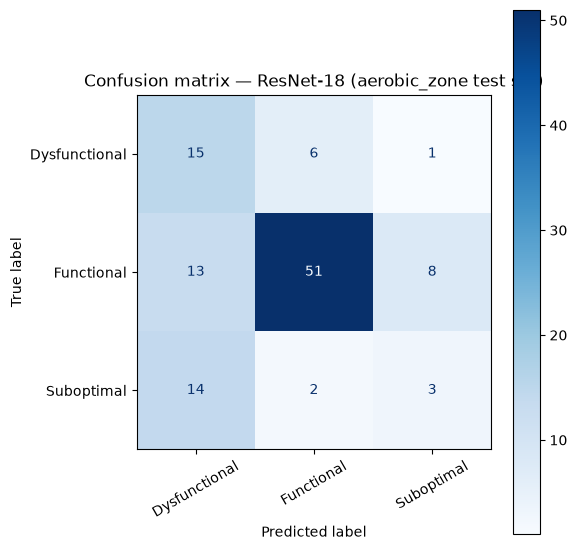

               precision    recall  f1-score   support

Dysfunctional      0.357     0.682     0.469        22
   Functional      0.864     0.708     0.779        72
   Suboptimal      0.250     0.158     0.194        19

     accuracy                          0.611       113
    macro avg      0.491     0.516     0.480       113
 weighted avg      0.662     0.611     0.620       113



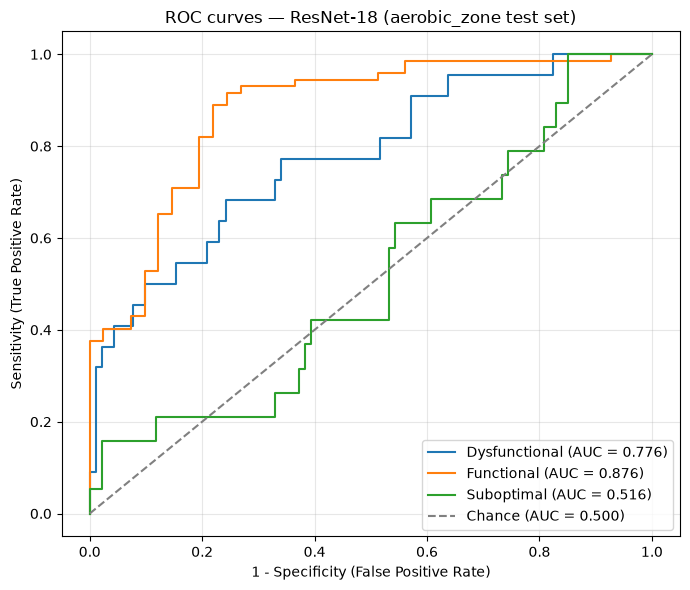

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.776
  Functional     : 0.876
  Suboptimal     : 0.516

Mean AUC (over 3/3 classes with test examples): 0.723


(np.float64(0.6106194690265486),
 {'Dysfunctional': 0.7762237762237763,
  'Functional': 0.8763550135501356,
  'Suboptimal': 0.5156774916013438})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_resnet18_Atlantis.pkl


Saved model weights to ../models/aerobic_zone_resnet18_cnn.pt
